## Pore descriptors, all test runs used in the paper can be found here.

## The MAE graphs that got created within the same train cell are incorrect, the right figures are at the end

In [2]:
#pip install pyzeo

4 features model (with gravimetric ASA), with explanations and notes, other without (but they have exactly the same structure).

In [ ]:
#
# ALIGNN + Pore Features Training Run
# What this cell does:
#   1. Configure and run the pore-augmented ALIGNN training
#   2. Plot the train/val MAE curve after training completes
#   3. Print a summary table of per-epoch MAE

import json
import os
import matplotlib.pyplot as plt

# Training configuration

from alignn.pore_utils import get_pore_loaders, sanity_check
from alignn.train import train_dgl
from alignn.config import TrainingConfig

config = TrainingConfig(
    dataset     = "hmof",
    target      = "surface_area_m2g",
    id_tag      = "id",
    train_ratio = 0.01,
    val_ratio   = 0.005,
    test_ratio  = 0.005,
    batch_size  = 4,
    epochs      = 5,
    output_dir  = "./output_pore_option_a",
)


# NOTE: pore_features 4
config.model.pore_features = 4

# Build pore-augmented data loaders

loaders = get_pore_loaders(config)

# Sanity check: prints the shape of the first batch so you can verify
# the pore tensor is present before starting a long training run.
# Expected output:
#   [0] g   : DGLGraph  num_nodes=...
#   [1] lg  : DGLGraph  num_nodes=...   ← line graph (bonds as nodes)
#   [2] lat : torch.Size([4, 3, 3])     ← lattice matrix
#   [3] pore: torch.Size([4, 4])        ← NEW: 4 pore descriptors per structure
#   [4] tgt : torch.Size([4])           ← surface area targets
#
# NOTE on the line graph count:
# The progress bars during LMDB construction show the number of STRUCTURES
# (e.g. 1376), not the number of graphs. For each structure, ALIGNN builds
# TWO graphs — the crystal graph G (atoms as nodes, bonds as edges) and
# the line graph L(G) (bonds as nodes, angles as edges). Both are stored
# together as a pair in the LMDB. The 1376 structures therefore produce
# 2 x 1376 = 2752 graphs in total, but the progress bar only counts
# structures because both graphs are built and stored in one step.
sanity_check(loaders[0], n_pore=4)

# Train

# NOTE on the BatchNorm error that previously occurred:
# The error "Expected more than 1 value per channel when training,
# got input size torch.Size([1, 64])" was caused by the pore_mlp using
# BatchNorm1d, which requires batch_size > 1. It crashed on the last
# batch of the test set when that batch happened to contain only 1 structure.
# This is FIXED in the current alignn.py by using LayerNorm instead of
# BatchNorm inside pore_mlp. LayerNorm normalises over the feature
# dimension rather than the batch dimension, so it works for any batch
# size including 1.

train_dgl(config, train_val_test_loaders=list(loaders))

# Plot MAE curve
# Reads history_train.json and history_val.json written during training.
# Divides the summed per-epoch L1 loss by the number of structures to get
# per-structure MAE, directly comparable to the baseline MAE printed at
# the start of training.

output_dir = config.output_dir
n_train    = 1376   # update if you change train_ratio
n_val      = 688    # update if you change val_ratio

train_path = os.path.join(output_dir, "history_train.json")
val_path   = os.path.join(output_dir, "history_val.json")

with open(train_path, "r") as f:
    history_train = json.load(f)
with open(val_path, "r") as f:
    history_val = json.load(f)


# [total_loss, graph_loss, atom_loss, grad_loss, stress_loss, addn_loss]
# We use index 1 (graph-level L1 loss) — the only active loss for ASA.
# History format per epoch (THIS IS OLD/INCORRECT):
train_mae = [epoch[1] / n_train for epoch in history_train]
val_mae   = [epoch[1] / n_val   for epoch in history_val]
epochs    = list(range(len(train_mae)))

best_val_epoch = val_mae.index(min(val_mae))
best_val_mae   = min(val_mae)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_mae, label="Train MAE", marker="o", linewidth=2)
ax.plot(epochs, val_mae,   label="Validation MAE", marker="s", linewidth=2)
ax.axvline(
    best_val_epoch, color="gray", linestyle="--", linewidth=1,
    label=f"Best val epoch {best_val_epoch} ({best_val_mae:.1f} m²/g)"
)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Mean Absolute Error (m²/g)", fontsize=13)
ax.set_title("ALIGNN + Pore Features (Option A) — Train vs Validation MAE",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()

mae_curve_path = os.path.join(output_dir, "mae_curve.png")
plt.savefig(mae_curve_path, dpi=150)
plt.show()
print(f"Saved MAE curve to {mae_curve_path}")

# Summary table

print(f"\n{'Epoch':>6}  {'Train MAE':>12}  {'Val MAE':>12}")
print("-" * 34)
for e, (tr, va) in enumerate(zip(train_mae, val_mae)):
    marker = "  <- best" if e == best_val_epoch else ""
    print(f"{e:>6}  {tr:>12.2f}  {va:>12.2f}{marker}")
print(f"\nBest validation MAE: {best_val_mae:.2f} m2/g at epoch {best_val_epoch}")

Using LMDB dataset.
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...


RunMAEBaseline MAE (predict mean) 1441 m²/g
Your earlier ALIGNN baseline (~1% data) 220 m²/g
ALIGNN + pore features (this run, 5 epochs) 73 m²/g

see output_pore_option_a

3 features model (wrong graph title as well)

Using LMDB dataset.
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
MAX val: 6947.3
MIN val: 0.0
MAD: 1466.1508943159604
Baseline MAE: 1441.5340029661302
data range 6534.1 0.0
line_graph True


100%|██████████| 1376/1376 [00:00<00:00, 2635325.25it/s]


Reading dataset sampletrain_data
data range 6383.5 0.0
line_graph True


100%|██████████| 688/688 [00:00<00:00, 3079702.40it/s]


Reading dataset sampleval_data
data range 6276.5 0.0
line_graph True


100%|██████████| 688/688 [00:00<00:00, 3220626.29it/s]

Reading dataset sampletest_data
n_train: 1376
n_val  : 688
n_test : 688


Loading hMOF pore descriptors for columns: ['void_fraction', 'pld', 'lcd']
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
  Loaded 137652 entries.
Pore-augmented splits: train=1376, val=688, test=688
Batch element shapes:
  [0] g   : DGLGraph  num_nodes=430
  [1] lg  : DGLGraph  num_nodes=5866
  [2] lat : torch.Size([4, 3, 3])
  [3] pore: torch.Size([4, 3])
  [4] tgt : torch.Size([4])

Sanity check passed — pore tensor shape: torch.Size([4, 3])
config: {'version': 'f2366daa3413d28a825b46e34d001b5549b05a40', 'dataset': 'hmof', 'target': 'surface_area_m2g', 'atom_features': 'cgcnn', 'neighbor_strategy': 'k-nearest', 'id_tag': 'id', 'dtype': 'float32', 'random_seed': 123, 'classification_threshold': None, 'n_val': None, 'n_test': None, 'n_train': None, 'train_ratio': 0.01, 'val_ratio': 0.005, 'test_ratio': 0.005, 'target_multiplication_factor': None, 'epochs': 5, 'batch_size': 4, 'weight_decay': 0.0, 'learning_ra

/home/milan/miniconda3/envs/mof/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             0        425174.0589 425174.0589 0.0000     0.0000     0.0000     0.0000     552.09    
Val Loss:    Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             0        131243.9282 131243.9282 0.0000     0.0000     0.0000     0.0000     121.76     Saving model
Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             1        222177.4225 222177.4225 0.0000     0.0000     0.0000     0.0000     489.07    
Val Loss:    Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             1        93676.2856 93676.2856 0.0000     0.0000     0.0000     0.0000     117.54     Saving model
Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             2        170337.9918 170337.9918 0.0000     0.0000     0.0000   

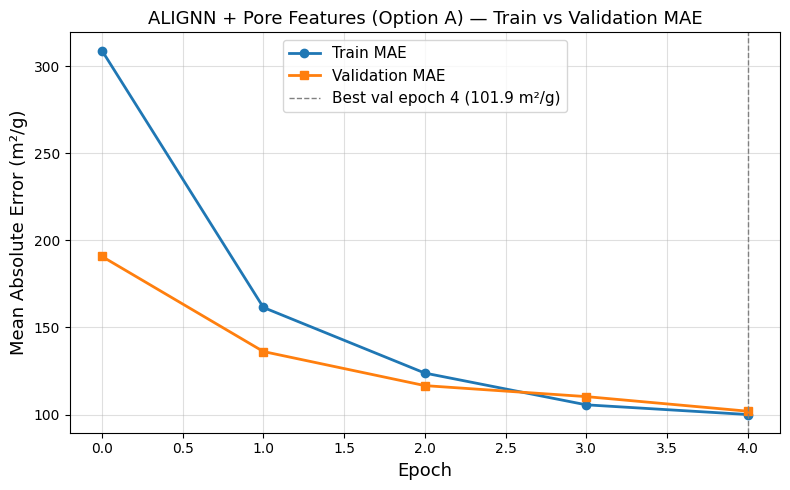

Saved MAE curve to ./output_pore_3feat/mae_curve.png

 Epoch     Train MAE       Val MAE
----------------------------------
     0        308.99        190.76
     1        161.47        136.16
     2        123.79        116.59
     3        105.55        110.28
     4         99.99        101.89  <- best

Best validation MAE: 101.89 m2/g at epoch 4


In [ ]:

import json
import os
import matplotlib.pyplot as plt

# Training configuration

from alignn.pore_utils import get_pore_loaders, sanity_check
from alignn.train import train_dgl
from alignn.config import TrainingConfig
import alignn.pore_utils as pu

# 3 geometric-only pore features (no surface_area_m2cm3)
pu.PORE_COLS = ["void_fraction", "pld", "lcd"]

config = TrainingConfig(
    dataset="hmof", target="surface_area_m2g", id_tag="id",
    train_ratio=0.01, val_ratio=0.005, test_ratio=0.005,
    batch_size=4, epochs=5,
    output_dir="./output_pore_3feat",  # different dir so you keep the 4-feat results
)

config.model.pore_features = 3
# Build pore-augmented data loaders
loaders = get_pore_loaders(config)
sanity_check(loaders[0], n_pore=3)

# Train
train_dgl(config, train_val_test_loaders=list(loaders))

# Plot MAE curve
output_dir = config.output_dir
n_train    = 1376   # update if you change train_ratio
n_val      = 688    # update if you change val_ratio

train_path = os.path.join(output_dir, "history_train.json")
val_path   = os.path.join(output_dir, "history_val.json")

with open(train_path, "r") as f:
    history_train = json.load(f)
with open(val_path, "r") as f:
    history_val = json.load(f)

train_mae = [epoch[1] / n_train for epoch in history_train]
val_mae   = [epoch[1] / n_val   for epoch in history_val]
epochs    = list(range(len(train_mae)))

best_val_epoch = val_mae.index(min(val_mae))
best_val_mae   = min(val_mae)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_mae, label="Train MAE", marker="o", linewidth=2)
ax.plot(epochs, val_mae,   label="Validation MAE", marker="s", linewidth=2)
ax.axvline(
    best_val_epoch, color="gray", linestyle="--", linewidth=1,
    label=f"Best val epoch {best_val_epoch} ({best_val_mae:.1f} m²/g)"
)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Mean Absolute Error (m²/g)", fontsize=13)
ax.set_title("ALIGNN + Pore Features (Option A) — Train vs Validation MAE",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()

mae_curve_path = os.path.join(output_dir, "mae_curve.png")
plt.savefig(mae_curve_path, dpi=150)
plt.show()
print(f"Saved MAE curve to {mae_curve_path}")

# Summary table
print(f"\n{'Epoch':>6}  {'Train MAE':>12}  {'Val MAE':>12}")
print("-" * 34)
for e, (tr, va) in enumerate(zip(train_mae, val_mae)):
    marker = "  <- best" if e == best_val_epoch else ""
    print(f"{e:>6}  {tr:>12.2f}  {va:>12.2f}{marker}")
print(f"\nBest validation MAE: {best_val_mae:.2f} m2/g at epoch {best_val_epoch}")

Run                               Features              Val   MAE      
Baseline (no pore)                   none                ~220 m²/g
Run 3 (geometry only)          void_fraction, pld, lcd   101.9 m²/g 
Run 2 (all 4 features)         + surface_area_m2cm3      73.9 m²/g       

Permutation Test (noise)

Using LMDB dataset.
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
MAX val: 6947.3
MIN val: 0.0
MAD: 1466.1508943159604
Baseline MAE: 1441.5340029661302
data range 6534.1 0.0
line_graph True


100%|██████████| 1376/1376 [00:00<00:00, 2425961.46it/s]


Reading dataset sampletrain_data
data range 6383.5 0.0
line_graph True


100%|██████████| 688/688 [00:00<00:00, 2390788.03it/s]


Reading dataset sampleval_data
data range 6276.5 0.0
line_graph True


100%|██████████| 688/688 [00:00<00:00, 3680715.76it/s]

Reading dataset sampletest_data
n_train: 1376
n_val  : 688
n_test : 688


Loading hMOF pore descriptors for columns: ['void_fraction', 'pld', 'lcd']
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
  *** PERMUTATION TEST ACTIVE — pore features are RANDOM NOISE ***
  Loaded 137652 entries.
Pore-augmented splits: train=1376, val=688, test=688
Batch element shapes:
  [0] g   : DGLGraph  num_nodes=611
  [1] lg  : DGLGraph  num_nodes=8268
  [2] lat : torch.Size([4, 3, 3])
  [3] pore: torch.Size([4, 3])
  [4] tgt : torch.Size([4])

Sanity check passed — pore tensor shape: torch.Size([4, 3])
config: {'version': 'f2366daa3413d28a825b46e34d001b5549b05a40', 'dataset': 'hmof', 'target': 'surface_area_m2g', 'atom_features': 'cgcnn', 'neighbor_strategy': 'k-nearest', 'id_tag': 'id', 'dtype': 'float32', 'random_seed': 123, 'classification_threshold': None, 'n_val': None, 'n_test': None, 'n_train': None, 'train_ratio': 0.01, 'val_ratio': 0.005, 'test_ratio': 0.005, 'target_multiplication_factor': No

/home/milan/miniconda3/envs/mof/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             0        465068.3601 465068.3601 0.0000     0.0000     0.0000     0.0000     570.45    
Val Loss:    Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             0        174701.6024 174701.6024 0.0000     0.0000     0.0000     0.0000     120.40     Saving model
Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             1        343194.0354 343194.0354 0.0000     0.0000     0.0000     0.0000     549.57    
Val Loss:    Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             1        164864.4644 164864.4644 0.0000     0.0000     0.0000     0.0000     120.39     Saving model
Train Loss:  Epoch    Total      Graph      Atom       Grad       Stress     Addn.      Time      
             2        331904.0680 331904.0680 0.0000     0.0000     0.0000 

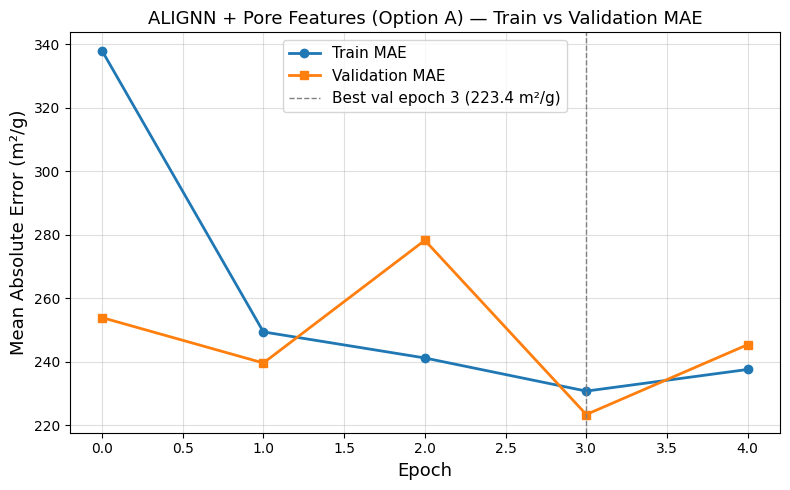

Saved MAE curve to ./output_leak_check/mae_curve.png

 Epoch     Train MAE       Val MAE
----------------------------------
     0        337.99        253.93
     1        249.41        239.63
     2        241.21        278.24
     3        230.78        223.41  <- best
     4        237.60        245.41

Best validation MAE: 223.41 m2/g at epoch 3


In [ ]:
import json
import os
import matplotlib.pyplot as plt
from alignn.pore_utils import get_pore_loaders, sanity_check
from alignn.train import train_dgl
from alignn.config import TrainingConfig
import alignn.pore_utils as pu

#3 geometric-only pore features (no surface_area_m2cm3)
pu.PORE_COLS = ["void_fraction", "pld", "lcd"]

# Training configuration
config = TrainingConfig(
    dataset="hmof", target="surface_area_m2g", id_tag="id",
    train_ratio=0.01, val_ratio=0.005, test_ratio=0.005,
    batch_size=4, epochs=5,
    output_dir="./output_leak_check",  # different dir so you keep the 4-feat results
)

config.model.pore_features = 3

# Build pore-augmented data loaders
loaders = get_pore_loaders(config)
sanity_check(loaders[0], n_pore=3)

# Train
train_dgl(config, train_val_test_loaders=list(loaders))

# Plot MAE curve
output_dir = config.output_dir
n_train    = 1376   # update if you change train_ratio
n_val      = 688    # update if you change val_ratio

train_path = os.path.join(output_dir, "history_train.json")
val_path   = os.path.join(output_dir, "history_val.json")

with open(train_path, "r") as f:
    history_train = json.load(f)
with open(val_path, "r") as f:
    history_val = json.load(f)

# History format per epoch:
train_mae = [epoch[1] / n_train for epoch in history_train]
val_mae   = [epoch[1] / n_val   for epoch in history_val]
epochs    = list(range(len(train_mae)))

best_val_epoch = val_mae.index(min(val_mae))
best_val_mae   = min(val_mae)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_mae, label="Train MAE", marker="o", linewidth=2)
ax.plot(epochs, val_mae,   label="Validation MAE", marker="s", linewidth=2)
ax.axvline(
    best_val_epoch, color="gray", linestyle="--", linewidth=1,
    label=f"Best val epoch {best_val_epoch} ({best_val_mae:.1f} m²/g)"
)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Mean Absolute Error (m²/g)", fontsize=13)
ax.set_title("ALIGNN + Pore Features (Option A) — Train vs Validation MAE",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()

mae_curve_path = os.path.join(output_dir, "mae_curve.png")
plt.savefig(mae_curve_path, dpi=150)
plt.show()
print(f"Saved MAE curve to {mae_curve_path}")

# Summary table
print(f"\n{'Epoch':>6}  {'Train MAE':>12}  {'Val MAE':>12}")
print("-" * 34)
for e, (tr, va) in enumerate(zip(train_mae, val_mae)):
    marker = "  <- best" if e == best_val_epoch else ""
    print(f"{e:>6}  {tr:>12.2f}  {va:>12.2f}{marker}")
print(f"\nBest validation MAE: {best_val_mae:.2f} m2/g at epoch {best_val_epoch}")

## Pore Model 3 features on Cluster

Cluster results

In [1]:
import json
import numpy as np
from sklearn.metrics import mean_absolute_error

for results_dir, label in [
    ('/home/milan/Downloads/alignn/results_m2g_141789',   'm2/g'),
    ('/home/milan/Downloads/alignn/results_m2cm3_141790', 'm2/cm3'),
]:
    with open(f'{results_dir}/Test_results.json') as f:
        test_results = json.load(f)

    targets, predictions = [], []
    for r in test_results:
        t, p = r['target_out'], r['pred_out']
        if isinstance(t, list):
            targets.extend(t)
            predictions.extend(p)
        else:
            targets.append(t)
            predictions.append(p)

    targets     = np.array(targets)
    predictions = np.array(predictions)
    mae = mean_absolute_error(targets, predictions)
    r2  = np.corrcoef(targets, predictions)[0,1]**2

    print(f"=== {label} ===")
    print(f"  N:   {len(targets)}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2:  {r2:.4f}")

=== m2/g ===
  N:   13765
  MAE: 82.06
  R2:  0.9948
=== m2/cm3 ===
  N:   13765
  MAE: 58.95
  R2:  0.9875


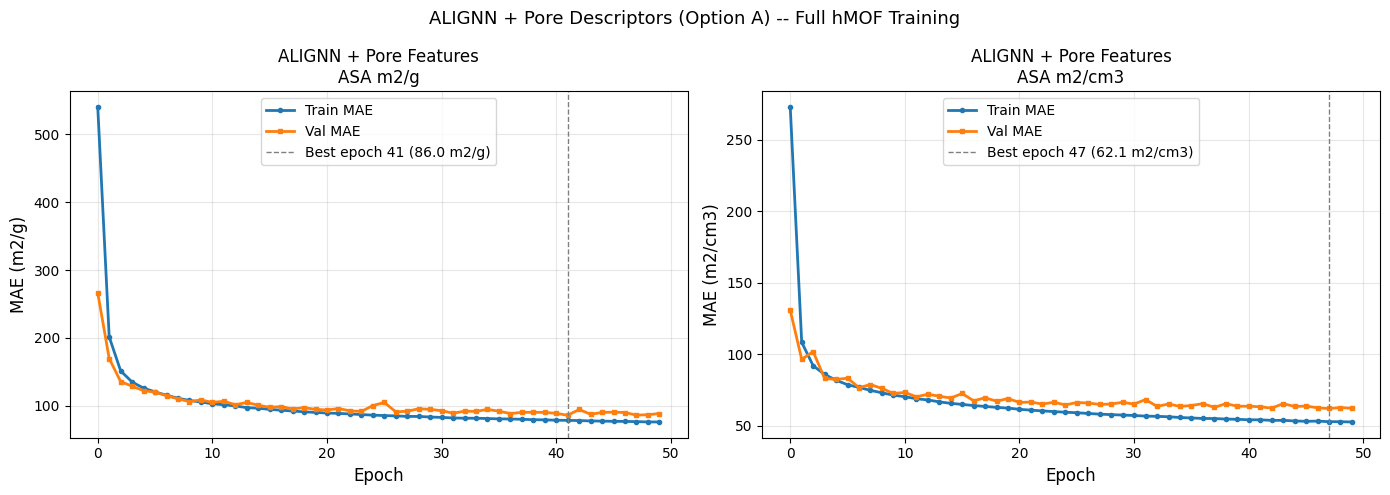

m2/g  -- Best val MAE: 86.02 m2/g   at epoch 41
m2/cm3 -- Best val MAE: 62.13 m2/cm3 at epoch 47


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# m2/g
with open('/home/milan/Downloads/alignn/results_m2g_141789/history_val.json') as f:
    history_val_m2g = json.load(f)
with open('/home/milan/Downloads/alignn/results_m2g_141789/history_train.json') as f:
    history_train_m2g = json.load(f)

# m2/cm3
with open('/home/milan/Downloads/alignn/results_m2cm3_141790/history_val.json') as f:
    history_val_m2cm3 = json.load(f)
with open('/home/milan/Downloads/alignn/results_m2cm3_141790/history_train.json') as f:
    history_train_m2cm3 = json.load(f)

n_train    = 110121
n_val      = 13765
batch_size = 16

def get_mae(history, n):
    return [(epoch[1] * batch_size) / n for epoch in history]

train_m2g   = get_mae(history_train_m2g,   n_train)
val_m2g     = get_mae(history_val_m2g,     n_val)
train_m2cm3 = get_mae(history_train_m2cm3, n_train)
val_m2cm3   = get_mae(history_val_m2cm3,   n_val)

epochs_m2g   = list(range(len(train_m2g)))
epochs_m2cm3 = list(range(len(train_m2cm3)))

best_m2g_epoch   = val_m2g.index(min(val_m2g))
best_m2cm3_epoch = val_m2cm3.index(min(val_m2cm3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: m2/g
ax = axes[0]
ax.plot(epochs_m2g, train_m2g, label='Train MAE', marker='o', markersize=3, linewidth=2)
ax.plot(epochs_m2g, val_m2g,   label='Val MAE',   marker='s', markersize=3, linewidth=2)
ax.axvline(best_m2g_epoch, color='gray', linestyle='--', linewidth=1,
           label=f'Best epoch {best_m2g_epoch} ({min(val_m2g):.1f} m2/g)')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MAE (m2/g)', fontsize=12)
ax.set_title('ALIGNN + Pore Features\nASA m2/g', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: m2/cm3
ax = axes[1]
ax.plot(epochs_m2cm3, train_m2cm3, label='Train MAE', marker='o', markersize=3, linewidth=2)
ax.plot(epochs_m2cm3, val_m2cm3,   label='Val MAE',   marker='s', markersize=3, linewidth=2)
ax.axvline(best_m2cm3_epoch, color='gray', linestyle='--', linewidth=1,
           label=f'Best epoch {best_m2cm3_epoch} ({min(val_m2cm3):.1f} m2/cm3)')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MAE (m2/cm3)', fontsize=12)
ax.set_title('ALIGNN + Pore Features\nASA m2/cm3', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('ALIGNN + Pore Descriptors (Option A) -- Full hMOF Training', fontsize=13)
plt.tight_layout()
plt.savefig('/home/milan/Downloads/alignn/mae_curves_both.png', dpi=150)
plt.show()

print(f'm2/g  -- Best val MAE: {min(val_m2g):.2f} m2/g   at epoch {best_m2g_epoch}')
print(f'm2/cm3 -- Best val MAE: {min(val_m2cm3):.2f} m2/cm3 at epoch {best_m2cm3_epoch}')

In [ ]:
import json
import numpy as np
import pandas as pd
from jarvis.db.figshare import data as jdata

# Load val results
with open('/home/milan/Downloads/alignn/results_m2cm3_141790/Test_results.json') as f:
    val_results = json.load(f)

# Load val IDs
with open('/home/milan/Downloads/alignn/results_m2cm3_141790/ids_train_val_test.json') as f:
    splits = json.load(f)S

val_ids = splits['id_val']
print(f"Val IDs: {len(val_ids)}")

# Flatten batches
targets, predictions = [], []
for r in val_results:
    t = r['target_out']
    p = r['pred_out']
    if isinstance(t, list):
        targets.extend(t)
        predictions.extend(p)
    else:
        targets.append(t)
        predictions.append(p)

print(f"Flattened structures: {len(targets)}")

# Load void fractions
print('Loading hMOF...')
raw = jdata('hmof')
vf_lookup = {str(d['id']): d.get('void_fraction', np.nan) for d in raw}

# Build dataframe
n = min(len(val_ids), len(targets))
df = pd.DataFrame({
    'id':            val_ids[:n],
    'target':        targets[:n],
    'prediction':    predictions[:n],
    'void_fraction': [vf_lookup.get(str(i), np.nan) for i in val_ids[:n]]
})

print(f"Rows: {len(df)}")
print(df.head())

# Save
df.to_csv('/home/milan/Downloads/alignn/results_m2cm3_141790/Test_predictions.csv', index=False)
print("Saved.")

Val IDs: 13765
Flattened structures: 13765
Loading hMOF...
Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.
Rows: 13765
             id       target   prediction  void_fraction
0  hMOF-6004981  1075.300049   935.872192       0.450413
1    hMOF-13161  2299.199951  2329.134033       0.847034
2     hMOF-6043  1832.599976  1799.088501       0.367415
3  hMOF-5040927  2166.300049  2221.024170       0.419832
4  hMOF-5033800  1994.900024  2071.232910       0.777181
Saved.


Obtaining hMOF dataset 137k...
Reference:https://doi.org/10.1021/acs.jpcc.6b08729
Loading the zipfile...
Loading completed.


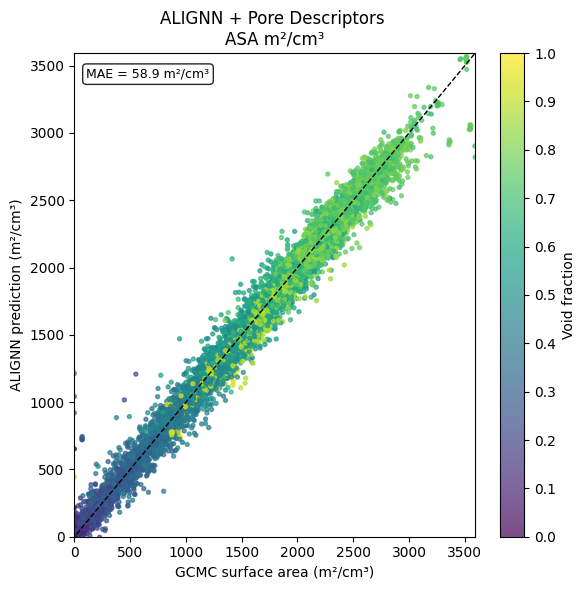

MAE: 58.95


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from jarvis.db.figshare import data as jdata

raw = jdata('hmof')
vf_lookup = {str(entry['id']): entry['void_fraction'] for entry in raw}

with open('/home/milan/Downloads/alignn/results_m2cm3_141790/Test_results.json') as f:
    test_results = json.load(f)

targets, predictions, jids = [], [], []
for r in test_results:
    t, p, jid = r['target_out'], r['pred_out'], r['id']
    if isinstance(t, list):
        targets.extend(t); predictions.extend(p); jids.extend([jid] * len(t))
    else:
        targets.append(t); predictions.append(p); jids.append(jid)

targets     = np.array(targets)
predictions = np.array(predictions)
vf          = np.clip(np.array([vf_lookup.get(str(j), 0.5) for j in jids]), 0.0, 1.0)

mae = np.abs(targets - predictions).mean()

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(targets, predictions, c=vf, cmap='viridis',
                s=8, alpha=0.7, vmin=0.0, vmax=1.0)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Void fraction')
cbar.set_ticks(np.arange(0, 1.1, 0.1))

min_val = min(targets.min(), predictions.min())
max_val = max(targets.max(), predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.text(0.03, 0.97, f'MAE = {mae:.1f} m²/cm³',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

ax.set_xlabel('GCMC surface area (m²/cm³)')
ax.set_ylabel('ALIGNN prediction (m²/cm³)')
ax.set_title('ALIGNN + Pore Descriptors \nASA m²/cm³')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()
print(f'MAE: {mae:.2f}')

In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

base = '/home/milan/Downloads/alignn/Thesis/Pores_Features_train'

runs = {
    'leak_check':       ('output_leak_check',     'ALIGNN + Pore Descriptors (permutation test)'),
    'pore_3feat':       ('output_pore_3feat',     'ALIGNN + Pore Descriptors (3 features)'),
    'pore_option_a':    ('output_pore_option_a',  'ALIGNN + Pore Descriptors + Vol. ASA (4 features)'),
}

def get_mae(results_path):
    with open(results_path) as f:
        results = json.load(f)
    targets, predictions = [], []
    for r in results:
        t, p = r['target_out'], r['pred_out']
        if isinstance(t, list):
            targets.extend(t)
            predictions.extend(p)
        else:
            targets.append(t)
            predictions.append(p)
    targets = np.array(targets)
    predictions = np.array(predictions)
    return mean_absolute_error(targets, predictions), targets, predictions

for key, (folder, title) in runs.items():
    path = os.path.join(base, folder)
    val_mae, val_t, val_p = get_mae(os.path.join(path, 'Val_results.json'))
    train_mae, train_t, train_p = get_mae(os.path.join(path, 'Train_results.json'))

    print(f'=== {title} ===')
    print(f'  Train MAE: {train_mae:.2f} m²/g  (N={len(train_t)})')
    print(f'  Val MAE:   {val_mae:.2f} m²/g  (N={len(val_t)})')
    print()

=== ALIGNN + Pore Descriptors (permutation test) ===
  Train MAE: 923.12 m²/g  (N=1376)
  Val MAE:   893.63 m²/g  (N=688)

=== ALIGNN + Pore Descriptors (3 features) ===
  Train MAE: 399.95 m²/g  (N=1376)
  Val MAE:   407.58 m²/g  (N=688)

=== ALIGNN + Pore Descriptors + Vol. ASA (4 features) ===
  Train MAE: 307.48 m²/g  (N=1376)
  Val MAE:   295.60 m²/g  (N=688)



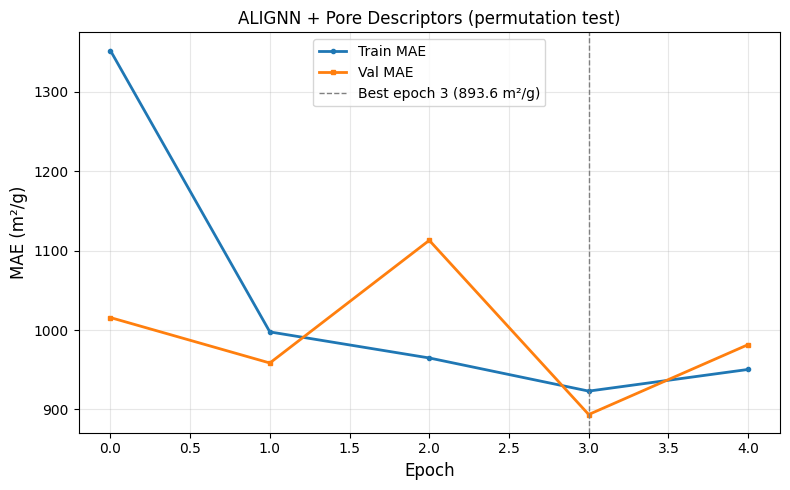

Saved: /home/milan/Downloads/alignn/Thesis/leak_check_mae_curve.png
Best val MAE: 893.63 m²/g at epoch 3



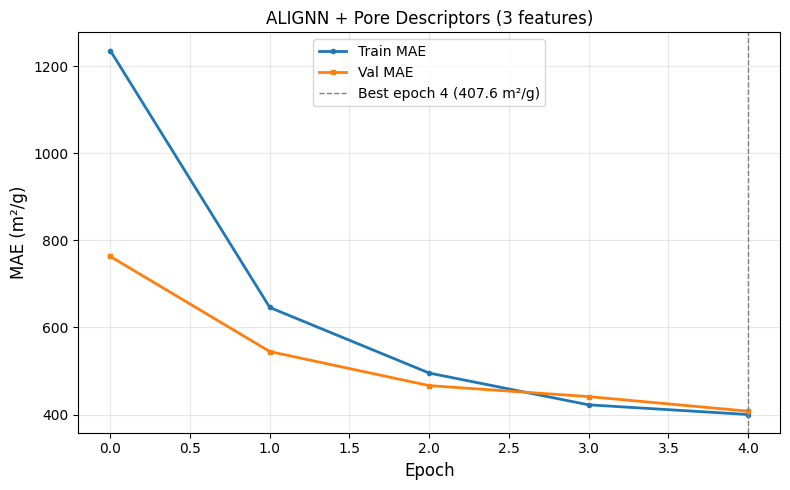

Saved: /home/milan/Downloads/alignn/Thesis/pore_3feat_mae_curve.png
Best val MAE: 407.58 m²/g at epoch 4



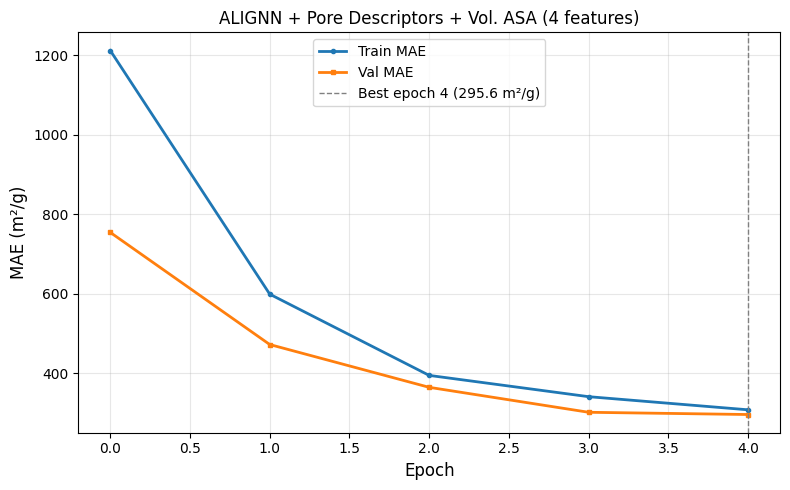

Saved: /home/milan/Downloads/alignn/Thesis/pore_option_a_mae_curve.png
Best val MAE: 295.60 m²/g at epoch 4



In [4]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

base = '/home/milan/Downloads/alignn/Thesis/Pores_Features_train'

runs = {
    'leak_check':    ('output_leak_check',    'ALIGNN + Pore Descriptors (permutation test)'),
    'pore_3feat':    ('output_pore_3feat',    'ALIGNN + Pore Descriptors (3 features)'),
    'pore_option_a': ('output_pore_option_a', 'ALIGNN + Pore Descriptors + Vol. ASA (4 features)'),
}

n_train    = 1376
n_val      = 688
batch_size = 4

for key, (folder, title) in runs.items():
    path = os.path.join(base, folder)

    with open(os.path.join(path, 'history_train.json')) as f:
        history_train = json.load(f)
    with open(os.path.join(path, 'history_val.json')) as f:
        history_val = json.load(f)

    train_mae = [(e[1] * batch_size) / n_train for e in history_train]
    val_mae   = [(e[1] * batch_size) / n_val   for e in history_val]
    epochs    = list(range(len(train_mae)))

    best_epoch = val_mae.index(min(val_mae))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, train_mae, label='Train MAE', marker='o', markersize=3, linewidth=2)
    ax.plot(epochs, val_mae,   label='Val MAE',   marker='s', markersize=3, linewidth=2)
    ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1,
               label=f'Best epoch {best_epoch} ({min(val_mae):.1f} m²/g)')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MAE (m²/g)', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10, loc='upper center')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f'/home/milan/Downloads/alignn/Thesis/{key}_mae_curve.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')
    print(f'Best val MAE: {min(val_mae):.2f} m²/g at epoch {best_epoch}\n')